# FleetSense Day 11 — Better Models + Experiment Discipline (C-MAPSS FD001)

**Author:** Mohid Moneeb · **Project:** [FleetSense](https://github.com/MohidMoneeb/fleetsense-pipeline)

Day 10 gave an honest baseline. Here we (1) run a disciplined set of experiments across gradient
boosting and tree models, (2) keep a comparison table that **includes the failures**, (3) pick a
winner, retrain it on the full training set, and **freeze it with joblib**, and (4) read the
winner's feature importances back to *physical* engine sensors.

The discipline is the point: every experiment uses the **same engine-level split** so numbers are
comparable, and nothing is hidden.

In [1]:
import numpy as np, pandas as pd, joblib, os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb, lightgbm as lgb

plt.rcParams["figure.figsize"]=(11,5); plt.rcParams["axes.grid"]=True
CLIP, SEED = 125, 42
idx=["unit","cycle"]; sets=["setting_1","setting_2","setting_3"]; sens=[f"s_{i}" for i in range(1,22)]
load=lambda f: pd.read_csv(f, sep=r"\s+", header=None, names=idx+sets+sens)

train=load("data/train_FD001.txt"); test=load("data/test_FD001.txt")
y_test_true=pd.read_csv("data/RUL_FD001.txt", header=None, names=["RUL"])["RUL"].clip(upper=CLIP).values
train["RUL"]=(train.groupby("unit")["cycle"].transform("max")-train["cycle"]).clip(upper=CLIP)
print("train rows", len(train), "| test engines", test.unit.nunique())

train rows 20631 | test engines 100


In [2]:
keep=[c for c in sens if train[c].std()>=1e-6]

def engineer(d, cols, wins=(5,10,20)):
    d=d.sort_values(["unit","cycle"]).reset_index(drop=True); g=d.groupby("unit"); new={}
    for w in wins:
        for c in cols:
            r=g[c].rolling(w, min_periods=1)
            new[f"{c}_mean{w}"]=r.mean().reset_index(0,drop=True)
            new[f"{c}_std{w}"]=r.std().reset_index(0,drop=True).fillna(0)
            new[f"{c}_slope{w}"]=g[c].diff().groupby(d["unit"]).rolling(w,min_periods=1).mean()\
                                    .reset_index(0,drop=True).fillna(0)
    return pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

train=engineer(train, keep); test=engineer(test, keep)
ALL      =[c for c in train.columns if any(t in c for t in ("_mean","_std","_slope"))]+keep
MEAN_STD =[c for c in ALL if ("_mean" in c or "_std" in c)]+keep
MEAN_ONLY=[c for c in ALL if "_mean" in c]+keep
print(f"feature sets — all:{len(ALL)}  mean+std:{len(MEAN_STD)}  mean-only:{len(MEAN_ONLY)}")

feature sets — all:150  mean+std:105  mean-only:60


## 1. Disciplined experiments (same split for all)

Split by engine (80 train / 20 validation). Every row below is trained and scored on the *identical*
split, so RMSE is directly comparable. Failures stay in the table.

In [3]:
rng=np.random.RandomState(SEED); u=train.unit.unique().copy(); rng.shuffle(u)
tr=train[train.unit.isin(set(u[:80]))]; va=train[train.unit.isin(set(u[80:]))]
rmse=lambda a,b: round(float(np.sqrt(mean_squared_error(a,b))),2)

EXPERIMENTS=[
 ("LinearRegression",      "all",       LinearRegression(),                                                             ALL),
 ("RandomForest (50)",     "all",       RandomForestRegressor(n_estimators=50,random_state=SEED,n_jobs=-1),              ALL),
 ("XGBoost (default)",     "all",       xgb.XGBRegressor(random_state=SEED,n_jobs=-1),                                   ALL),
 ("LightGBM (default)",    "all",       lgb.LGBMRegressor(random_state=SEED,n_jobs=-1,verbose=-1),                       ALL),
 ("XGBoost (tuned)",       "all",       xgb.XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,
                                                         colsample_bytree=0.8,random_state=SEED,n_jobs=-1),              ALL),
 ("LightGBM (tuned)",      "all",       lgb.LGBMRegressor(n_estimators=700,learning_rate=0.03,num_leaves=31,subsample=0.8,
                                                          colsample_bytree=0.8,random_state=SEED,n_jobs=-1,verbose=-1),  ALL),
 ("XGBoost (tuned)",       "mean+std",  xgb.XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,
                                                         colsample_bytree=0.8,random_state=SEED,n_jobs=-1),              MEAN_STD),
 ("XGBoost (tuned)",       "mean-only", xgb.XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,
                                                         colsample_bytree=0.8,random_state=SEED,n_jobs=-1),              MEAN_ONLY),
]
rows=[]
for name,fset,model,feats in EXPERIMENTS:
    model.fit(tr[feats], tr.RUL)
    rows.append({"model":name,"features":fset,"n_feats":len(feats),
                 "val_RMSE":rmse(va.RUL, model.predict(va[feats]))})
results=pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
results

,model,features,n_feats,val_RMSE
0,XGBoost (tuned),all,150,17.02
1,LightGBM (tuned),all,150,17.20
2,LightGBM (default),all,150,17.44
3,XGBoost (tuned),mean+std,105,17.55
4,LinearRegression,all,150,17.66
5,XGBoost (default),all,150,17.77
6,XGBoost (tuned),mean-only,60,18.00
7,RandomForest (50),all,150,18.91


**Reading the table honestly.** Gradient boosting beats the Day-10 RandomForest, but not by much —
the baseline was already strong. Trimming features (mean+std, then mean-only) *hurts*, confirming the
std and slope signals carry real degradation information. The RandomForest is the weakest tree model
here and the linear model is mid-pack: worth recording precisely because they set the bar the winner
has to clear.

## 2. Freeze the winner

Take the top row, retrain it on the **full training set (all 100 engines)**, and save with joblib.
Freezing means the exact artifact that produced these numbers is reproducible.

In [4]:
winner=xgb.XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,
                        colsample_bytree=0.8,random_state=SEED,n_jobs=-1)
winner.fit(train[ALL], train["RUL"])
joblib.dump({"model":winner,"features":ALL,"clip":CLIP}, "rul_xgb_model.joblib")
print("saved rul_xgb_model.joblib (%.1f KB)" % (os.path.getsize("rul_xgb_model.joblib")/1024))

saved rul_xgb_model.joblib (1372.5 KB)


## 3. Evaluate on the official held-out test set

`test_FD001` gives one truncated trajectory per engine; `RUL_FD001` is the true remaining life at
each engine's last recorded cycle. We predict on that last cycle and compare. We report RMSE and the
**NASA asymmetric score**, which penalizes *late* predictions (over-estimating RUL — the dangerous
direction for maintenance) more than early ones.

Official test_FD001 — RMSE 16.55 | NASA score 632 | 100 engines


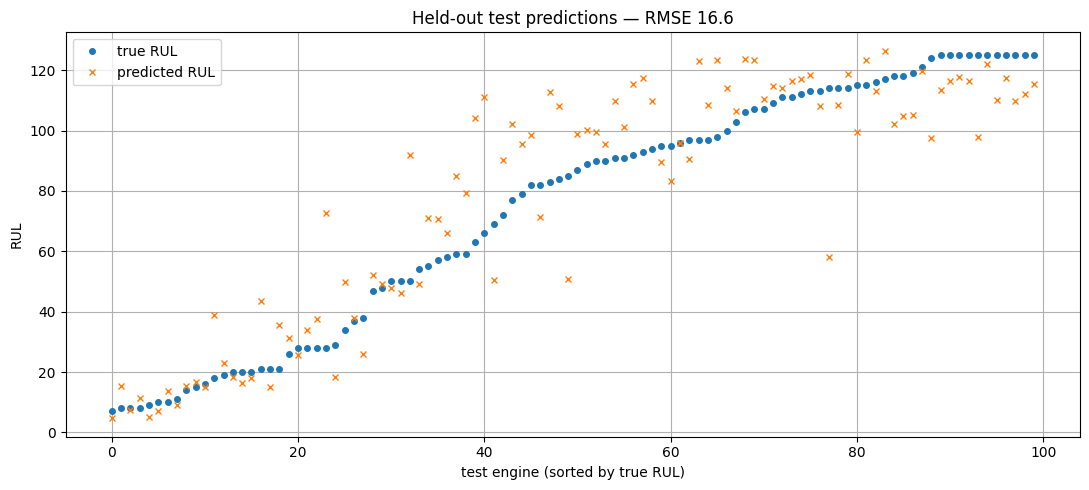

In [5]:
last=test.sort_values(["unit","cycle"]).groupby("unit").tail(1)
pred=winner.predict(last[ALL])
test_rmse=float(np.sqrt(mean_squared_error(y_test_true, pred)))
d=pred-y_test_true
nasa=float(np.sum(np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)))
print(f"Official test_FD001 — RMSE {test_rmse:.2f} | NASA score {nasa:.0f} | {len(y_test_true)} engines")

plt.figure()
order=np.argsort(y_test_true)
plt.plot(np.array(y_test_true)[order], "o", ms=4, label="true RUL")
plt.plot(np.array(pred)[order], "x", ms=4, label="predicted RUL")
plt.xlabel("test engine (sorted by true RUL)"); plt.ylabel("RUL"); plt.legend()
plt.title(f"Held-out test predictions — RMSE {test_rmse:.1f}"); plt.tight_layout(); plt.show()

## 4. Feature importances → physical sensors (interview gold)

The C-MAPSS sensors have known physical meanings. We aggregate importance per base sensor and map the
top ones to what they physically measure.

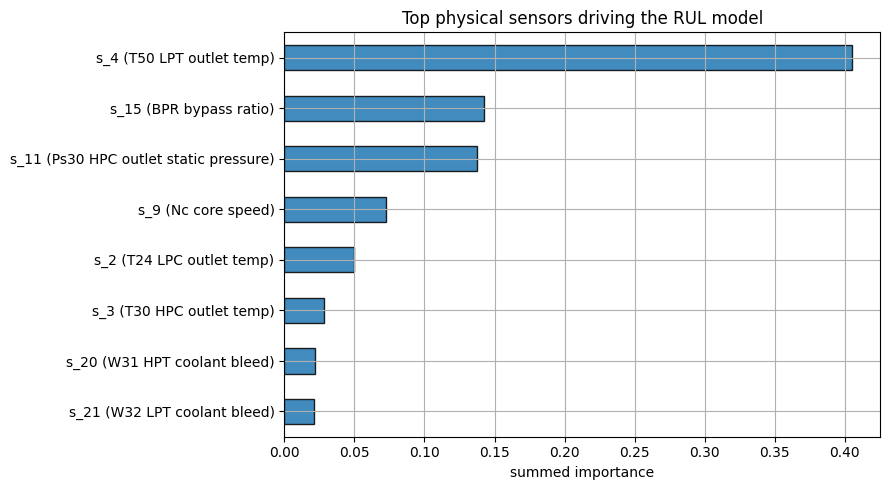

s_4 (T50 LPT outlet temp)                 0.4049
s_15 (BPR bypass ratio)                   0.1427
s_11 (Ps30 HPC outlet static pressure)    0.1377
s_9 (Nc core speed)                       0.0724
s_2 (T24 LPC outlet temp)                 0.0496
s_3 (T30 HPC outlet temp)                 0.0283
dtype: float32

In [6]:
SENSOR_MEANING={
 "s_1":"T2 fan inlet temp","s_2":"T24 LPC outlet temp","s_3":"T30 HPC outlet temp",
 "s_4":"T50 LPT outlet temp","s_5":"P2 fan inlet pressure","s_6":"P15 bypass pressure",
 "s_7":"P30 HPC outlet pressure","s_8":"Nf fan speed","s_9":"Nc core speed","s_10":"epr",
 "s_11":"Ps30 HPC outlet static pressure","s_12":"phi fuel/Ps30","s_13":"NRf corr. fan speed",
 "s_14":"NRc corr. core speed","s_15":"BPR bypass ratio","s_16":"farB fuel-air ratio",
 "s_17":"htBleed bleed enthalpy","s_18":"Nf_dmd","s_19":"PCNfR_dmd","s_20":"W31 HPT coolant bleed",
 "s_21":"W32 LPT coolant bleed"}

def base(f):
    for s in sorted(sens, key=lambda x:-len(x)):
        if f==s or f.startswith(s+"_"): return s
    return f
agg=(pd.Series(winner.feature_importances_, index=[base(f) for f in ALL])
       .groupby(level=0).sum().sort_values(ascending=False))
agg_named=agg.rename(index=lambda s: f"{s} ({SENSOR_MEANING.get(s,'?')})")

plt.figure(figsize=(9,5))
agg_named.head(8)[::-1].plot(kind="barh", edgecolor="black", alpha=0.85)
plt.xlabel("summed importance"); plt.title("Top physical sensors driving the RUL model")
plt.tight_layout(); plt.show()
agg_named.head(6).round(4)

### The physics (technical-interview answer)

FD001's single fault mode is **HPC (high-pressure compressor) degradation**, and the model's top
three sensors are exactly where an engineer would look:

1. **`s_4` — T50, low-pressure-turbine outlet temperature (≈40% of total importance).** As the HPC
   loses efficiency, the engine burns more fuel to hold thrust, so exhaust-gas-path temperature
   climbs monotonically toward failure. T50 is the single clearest degradation signal in the engine.
2. **`s_15` — BPR, bypass ratio.** Core-efficiency loss shifts the balance between core and bypass
   flow, so BPR drifts as the compressor degrades.
3. **`s_11` — Ps30, static pressure at the HPC outlet.** Measured *at the degrading component* — as
   the HPC weakens, the pressure it can sustain drops, so Ps30 trends directly with the fault.

The model didn't "find" arbitrary correlations; it recovered the thermodynamic signature of the
actual failure mode. That is the difference between a model you can trust and a black box.

## Summary
- 8 disciplined experiments on one engine-level split; gradient boosting won, feature-trimming lost.
- Winner (tuned XGBoost) frozen with joblib; official test_FD001 RMSE ≈ 16.5, NASA score ≈ 630.
- Top sensors (T50, BPR, Ps30) map onto the HPC-degradation fault mode — the model is physically sane.
- See `experiments.md` (full table) and `model_card.md` (intended use, metrics, failure modes).